# Librerías

In [ ]:
import numpy as np # manejo de arreglos
import matplotlib.pyplot as plt # para graficar

from scipy.integrate import solve_ivp
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html

plt.rcParams["figure.figsize"] = (10,5) #tamaño de los gráficos: ancho x alto

# `solve_ivp` para resolver EDOs.


## Ejemplo:
Retomando el uso de solve_ivp, aplicarlo para aproximar numéricamente la solución de:
$$ y' = xcos(y)$$




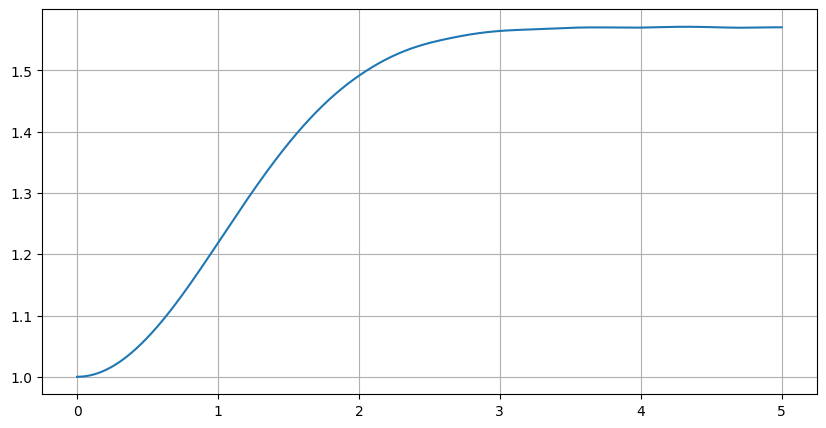

In [ ]:
# definimos la función
def func(x,y):
    dy = x*np.cos(y)
    return dy

# condiciones iniciales e intervalo.
y0 = [1] #vector de condiciones iniciales
x0 = 0 #tiempo inicial
xf = 5 #tiempo final

# solve_ivp recibe: función, intervalo de tiempo y condicione iniciales
solucion = solve_ivp(func, [x0, xf], y0, dense_output = True)

# graficamos la solución
vals_x = np.linspace(x0,xf,1000)
vals_sol = solucion.sol(vals_x)
plt.plot(vals_x, vals_sol.T) # el .T es transponer. Es por como devuelve la solución solve_ivp
plt.grid() #marcas horizontales y verticales de refencia

In [ ]:
print(solucion) #observar toda lo que da de salida

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e-04  1.100e-03  1.110e-02  1.111e-01
             1.111e+00  2.006e+00  2.649e+00  3.291e+00  3.988e+00
             4.754e+00  5.000e+00]
        y: [[ 1.000e+00  1.000e+00  1.000e+00  1.000e+00  1.003e+00
              1.257e+00  1.492e+00  1.553e+00  1.568e+00  1.570e+00
              1.570e+00  1.571e+00]]
      sol: <scipy.integrate._ivp.common.OdeSolution object at 0x7ed2c067c790>
 t_events: None
 y_events: None
     nfev: 80
     njev: 0
      nlu: 0


In [ ]:
print(solucion.t), len( solucion.t)

[0.00000000e+00 1.00000000e-04 1.10000000e-03 1.11000000e-02
 1.11100000e-01 1.11110000e+00 2.00629858e+00 2.64883117e+00
 3.29136376e+00 3.98847291e+00 4.75363110e+00 5.00000000e+00]


(None, 12)

In [ ]:
print(solucion.y) # son los y de los t que elije en solucion.t
print((solucion.y.shape))


[[1.         1.         1.00000033 1.00003328 1.00332588 1.25691741
  1.49240086 1.55280649 1.56762715 1.56998056 1.56990039 1.57052554]]
(1, 12)


In [ ]:
print(solucion.sol)

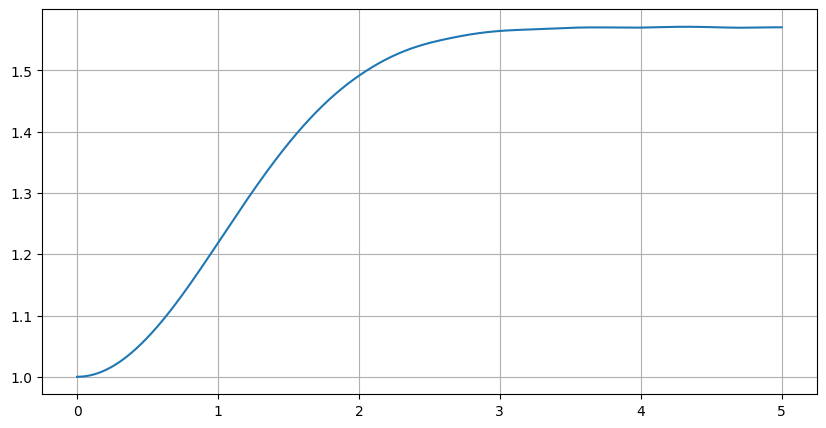

In [ ]:
# borrar, otra manera de usar el solve


# definimos la función
def func(x, y):
    dy = x*np.cos(y)
    return dy

# condiciones iniciales e intervalo.
y0 = [1] #vector de condiciones iniciales
x0 = 0 #tiempo inicial
xf = 5 #tiempo final
vals_x = np.linspace(x0,xf,1000)
# solve_ivp recibe: función, intervalo de tiempo y condicione iniciales
solucion = solve_ivp(func, [x0, xf], y0, dense_output = True, t_eval=vals_x)

# graficamos la solución

vals_sol = solucion.y.T
plt.plot(vals_x, vals_sol) # el .T es transponer. Es por como devuelve la solución solve_ivp
plt.grid() #marcas horizont

### Mismo ejemplo pero resolviendo varias condiciones iniciales al mismo tiempo

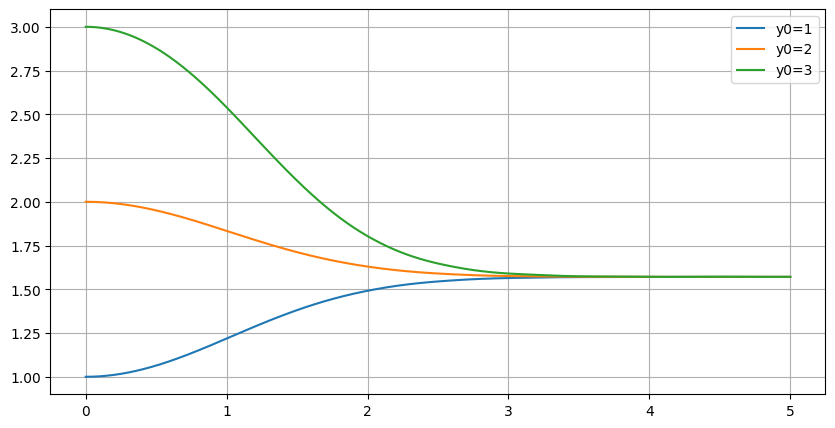

In [ ]:
# definimos la función
def func(x,y):
    dy = x*np.cos(y)
    return dy

# condiciones iniciales e intervalo.
y0 = [1, 2, 3] #vector de condiciones iniciales. Resolvemos muchos al mismo tiempo
x0 = 0 #tiempo inicial
xf = 5 #tiempo final

# solve_ivp recibe: función, intervalo de tiempo y condicione iniciales
solucion = solve_ivp(func, [x0, xf], y0, dense_output = True)

# graficamos la solución
vals_x = np.linspace(x0,xf,1000)
vals_sol = solucion.sol(vals_x)
plt.plot(vals_x, vals_sol.T) # el .T es transponer. Es por como devuelve la solución solve_ivp
plt.legend(['y0=1', 'y0=2', 'y0=3'])
plt.grid() #marcas horizontales y verticales de refencia

# Resolver el mismo PVI de manera gráfica usando la página https://homepages.bluffton.edu/~nesterd/apps/slopefields.html y comparar



---



---



# Ejercicio:
1- Resolver el ejercicio 3d) de la práctica 1-Segunda parte- usando solve_ivp para distintas cond iniciales y graficar.
2- Comparar resultados usando https://homepages.bluffton.edu/~nesterd/apps/slopefields.html

# Ejercicio 3
d) $$
y'=2y(y-1)
$$
con

i) y(-1)=1 \\
ii) y(0)=1.25 \\
iii) y(0)=0.5 \\
iv) y(1)=0 \\
v) y(0)= -0.5 \\


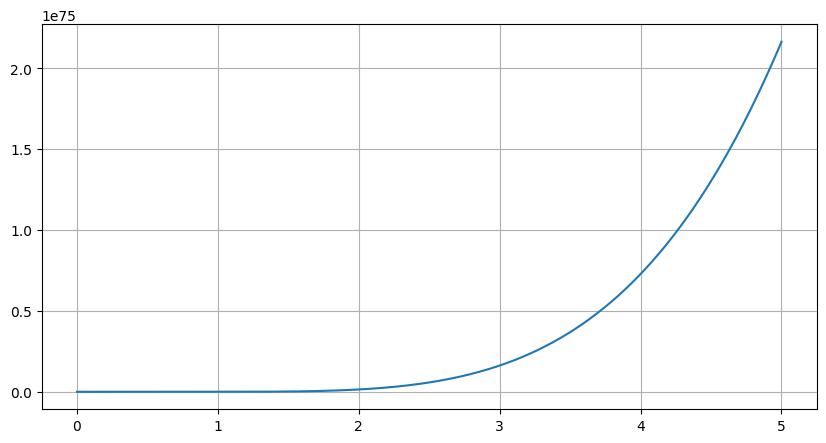

In [ ]:
# definimos la función, primero hacemos con una sola cond inicial
def func(x,y):
    dy = 2*y*(y-1)
    return dy

# condiciones iniciales e intervalo.
y0 = [1.25] #vector de condiciones iniciales
x0 = 0 #tiempo inicial
xf = 5 #tiempo final
vals_x = np.linspace(x0,xf,1000)

# solve_ivp recibe: función, intervalo de tiempo y condicione iniciales
solucion = solve_ivp(func, [x0, xf], y0, dense_output = True,t_eval=vals_x )

# graficamos la solución

vals_sol = solucion.sol(vals_x)
plt.plot(vals_x, vals_sol.T) # el .T es transponer. Es por como devuelve la solución solve_ivp
plt.grid() #marcas horizontales y verticales de refencia

'\nno nos conviene hacer todas las cond juntas ya que hay lio de escala, con y0=1.25 se va muy arriba\n'

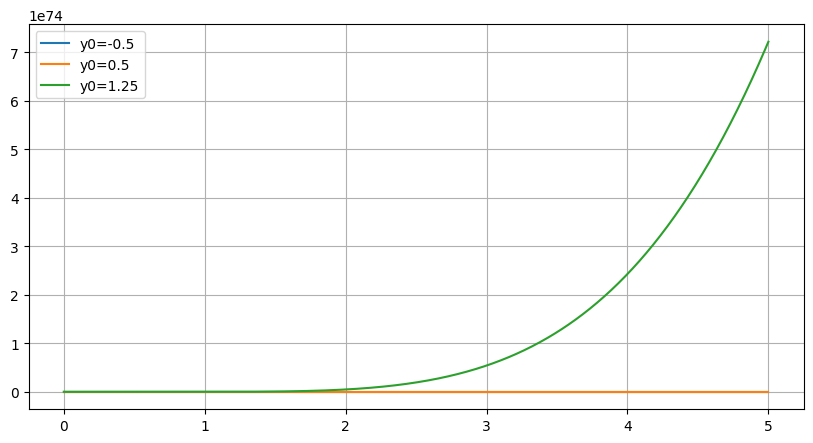

In [ ]:
# ahora agrupamos las cond iniciales que arrancan en el mismo x

# definimos la función
def func(x,y):
    dy = 2*y*(y-1)
    return dy


# condiciones iniciales e intervalo.
y0 = [-.5, 0.5, 1.25] #vector de condiciones iniciales. Resolvemos muchos al mismo tiempo
x0 = 0 #tiempo inicial
xf = 5 #tiempo final
vals_x = np.linspace(x0,xf,1000)
# solve_ivp recibe: función, intervalo de tiempo y condicione iniciales
solucion = solve_ivp(func, [x0, xf], y0, dense_output = True)

# graficamos la solución

vals_sol = solucion.sol(vals_x)
plt.plot(vals_x, vals_sol.T) # el .T es transponer. Es por como devuelve la solución solve_ivp
plt.legend(['y0=-0.5', 'y0=0.5', 'y0=1.25'])


plt.grid() #marcas horizontales y verticales de refencia

'''
no nos conviene hacer todas las cond juntas ya que hay lio de escala, con y0=1.25 se va muy arriba
'''

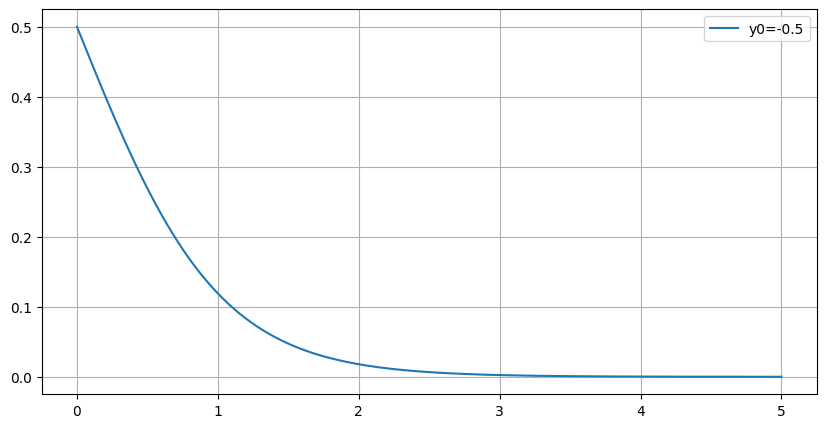

In [ ]:
# pruebo cada cond por separado

# definimos la función
def func(x,y):
    dy = 2*y*(y-1)
    return dy


# condiciones iniciales e intervalo.
y0 = [0.5] #ir cambiando aca
#y0 = [-.5, 0.5, 1.25]
x0 = 0 #tiempo inicial
xf = 5 #tiempo final
vals_x = np.linspace(x0,xf,1000)
# solve_ivp recibe: función, intervalo de tiempo y condicione iniciales
solucion = solve_ivp(func, [x0, xf], y0, dense_output = True)

# graficamos la solución

vals_sol = solucion.sol(vals_x)
plt.plot(vals_x, vals_sol.T) # el .T es transponer. Es por como devuelve la solución solve_ivp
plt.legend(['y0=-0.5', 'y0=0.5', 'y0=1.25'])
#plt.ylim(-0.7, 7)

plt.grid() #marcas horizontales y verticales de refencia



# Repetir con cada cond inicial y comparar.

**Nota:** para resolver tamnbien esta odeint, la dif que solve_ivp es mas completo y se puede elegir el metodo de resolucion. Si elegimos como método = 'LSODA', utilizará el mismo integrador que odeint.

##**Campo de pendientes**
# En esta sección hacemos el campo de pendientes nosotros usando Python

---
---
---
---


## Ejemplo: graficar el campo de pendientes para $0 \leq x \leq 5$ y para $0 \leq y \leq 4$ de: $$ y' = x\cos(y)$$

## Comparar el campo de pendientes con las soluciones encontradas antes por `solve_ivp`.

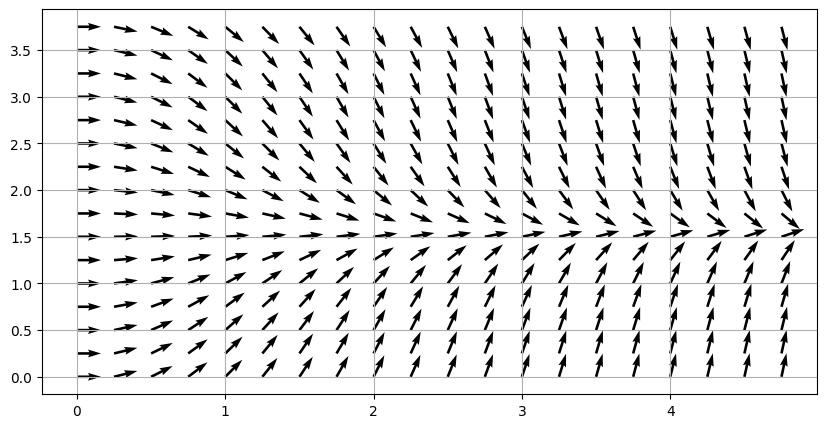

In [ ]:
# https://numpy.org/doc/stable/reference/generated/numpy.arange.html
valores_x = np.arange(0, 5, 0.25) #inicio, fin, paso
valores_y = np.arange(0, 4, 0.25)

# creo la malla de puntos: en cada punto voy a graficar un vector con pendiente
# dada por y'
# https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html
X, Y = np.meshgrid(valores_x, valores_y)
# print(X)


# https://numpy.org/doc/stable/reference/generated/numpy.ones_like.html
# Creamos los vectores de pendientes
U = np.ones_like(X) #en x que sea 1, total la pendiente viene dada por y.
#La sentencia np.ones_like(X) crea un nuevo array con la misma forma y tipo de datos que X, pero con todos sus elementos establecidos en 1.
V = X*np.cos(Y) # fijense qu eesto sería la m de cada (X,Y)
# print(U)

# normalizo los vectores para que todos midan 1
# queda mejor estéticamente en el gráfico
magnitud = np.sqrt(U**2 + V**2)
U = U/magnitud
V = V/magnitud

# grafico malla vs. vectores
plt.quiver(X, Y, U, V) # une cada (X,Y) de la meshgrid con (U,V). Al poner U=1,"sube V" que seria la m
plt.grid() #marcas horizontales y verticales de refencia

# Graficamos en un mismo gráfico las soluciones encontradas por `solve_ivp` y el campo de pendientes


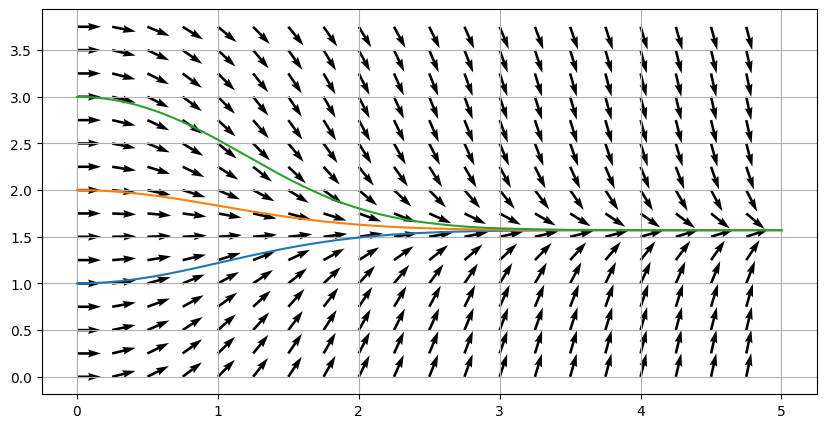

In [ ]:
#Solución por solve_ivp

# definimos la función
def func(x,y):
    dy = x*np.cos(y)
    return dy

# condiciones iniciales e intervalo.
y0 = [1, 2, 3] #vector de condiciones iniciales. Resolvemos muchos al mismo tiempo
x0 = 0 #tiempo inicial
xf = 5 #tiempo final

# solve_ivp recibe: función, intervalo de tiempo y condicione iniciales
solucion = solve_ivp(func, [x0, xf], y0, dense_output = True)

# graficamos la solución
vals_x = np.linspace(x0,xf,1000)
vals_sol = solucion.sol(vals_x)
plt.plot(vals_x, vals_sol.T) # el .T es transponer. Es por como devuelve la solución solve_ivp




###################################################
# Campo de pendientes

# https://numpy.org/doc/stable/reference/generated/numpy.arange.html
valores_x = np.arange(0, 5, 0.25) #inicio, fin, paso
valores_y = np.arange(0, 4, 0.25)

# creo la malla de puntos: en cada punto voy a graficar un vector con pendiente
# dada por y'
# https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html
X, Y = np.meshgrid(valores_x, valores_y)
# print(X)


# https://numpy.org/doc/stable/reference/generated/numpy.ones_like.html
# Creamos los vectores de pendientes
U = np.ones_like(X) #en x que sea 1, total la pendiente viene dada por y
V = X*np.cos(Y)
# print(U)

# normalizo los vectores para que todos midan 1
# queda mejor estéticamente en el gráfico
magnitud = np.sqrt(U**2 + V**2)
U = U/magnitud
V = V/magnitud

# grafico malla vs. vectores
plt.quiver(X, Y, U, V)

plt.grid() #marcas horizontales y verticales de refencia